In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import pickle

In [3]:
df = pd.read_csv("demand_forecasting.csv")

In [4]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='str')

In [5]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [6]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [7]:
target = "Demand"

In [8]:
x = df[features].copy()
y = df[target]

In [9]:
x

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [10]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [11]:
label_encoders = {}

categorical_cols = x.select_dtypes(include="object").columns

C:\Users\ramvi\AppData\Local\Temp\ipykernel_23092\791559217.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include="object").columns


In [12]:
categorical_cols

Index(['Category'], dtype='str')

In [13]:
for col in categorical_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col] = le

In [14]:
label_encoders

{'Category': LabelEncoder()}

In [ ]:
#le = LabelEncoder()
#x["Category"] = le.fit_transform(x["Category"])

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2)

In [17]:
xgb = XGBRegressor(objective= "reg:squarederror", n_jobs =-1)

In [18]:
param_dict ={
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

In [19]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dict,
    n_iter = 25,
    scoring = "neg_mean_absolute_error",
    cv = 3,
    verbose = 1,
    n_jobs = -1,
)

In [20]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [21]:
random_search.best_params_

{'subsample': 1.0,
 'n_estimators': 300,
 'min_child_weight': 3,
 'max_depth': 6,
 'learning_rate': 0.1,
 'colsample_bytree': 1.0}

In [22]:
best_model = random_search.best_estimator_

In [23]:
y_pred=best_model.predict(x_test)

In [24]:
mean_squared_error(y_test, y_pred, squared= False)

35.55310258564195

In [25]:
best_model.feature_importances_

array([0.09196183, 0.02463462, 0.01933379, 0.5660895 , 0.03062389,
       0.26735628], dtype=float32)

In [26]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = x.columns
).sort_values(ascending= False)

In [27]:
feature_importance

Promotion             0.566090
Category              0.267356
Price                 0.091962
Competitor Pricing    0.030624
Discount              0.024635
Inventory Level       0.019334
dtype: float32

<Axes: title={'center': 'Feature Importances'}>

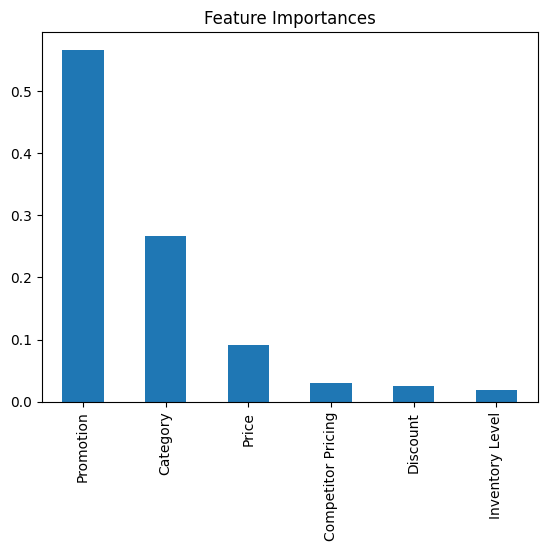

In [28]:
feature_importance.plot(kind="bar", title= "Feature Importances")

In [29]:
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

In [30]:
with open("xgboost_demand_model.pkl","wb") as f:
    pickle.dump(best_model, f)